# PROJECT 2: MODEL ANALYSIS 

**IMPORTING PACKAGES**

In [7]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
from Consumer import ConsumerClass

**PROBLEM 1:  A consumer with two nests**

**PROBLEM 1.1**

**PROBLEM 1.2**

In [8]:
# We import the ConsumerClass from the Consumer module
from Consumer import ConsumerClass

# Calibration 1: Complements (uses sigma_b = 0.4)
model_comp = ConsumerClass()

# Calibration 2: creating the "substitutes model"
model_sub = ConsumerClass(par={'sigma_B': 3.0})

**PROBLEM 1.3**

We solve this after we have run the simulations in PROBLEM 2. 

**PROBLEM 2: Solving the model numerically**

**PROBLEM 2.1**

**2.1.1**

In [ ]:
# a. setup of models
model_comp = ConsumerClass() # Complements
model_sub = ConsumerClass(par={'sigma_B': 3.0}) # Substitutes

# b. solving models
sol_comp = model_comp.solve_grid(N=100, do_print=False) #solving the complements model with a grid of 100 points.
sol_sub = model_sub.solve_grid(N=100, do_print=False) #solving the substitutes model with a grid of 100 points.

# c. function to print results
def print_results(sol, title):
    """ Prints the nested and budget shares """
    print(f"--- {title} ---")
    print(f"Nested shares : s1 = {sol.s1:.4f}, w = {sol.w:.4f}")
    print(f"Budget shares : s1 = {sol.s1:.4f}, s2 = {sol.s2:.4f}, s3 = {sol.s3:.4f}")
    print(f"Max Utility   : {sol.u:.4f}\n")

# d. printing results
print_results(sol_comp, "Complements")
print_results(sol_sub, "Substitutes")

--- Complements ---
Nested shares : s1 = 0.5354, w = 0.4444
Budget shares : s1 = 0.5354, s2 = 0.2065, s3 = 0.2581
Max Utility   : 3.4015

--- Substitutes ---
Nested shares : s1 = 0.5354, w = 0.6970
Budget shares : s1 = 0.5354, s2 = 0.3238, s3 = 0.1408
Max Utility   : 3.4850



The grid search yields an interior solution for both calibrations. The optimal food share, s 
1
​	
 , is approximately 0.535 in both cases, while the allocation within the travel nest differs considerably. With complements, the travel budget is relatively evenly divided between bus and train, with w≈0.444. With substitutes, a substantially larger share of the travel budget is allocated to bus trips, with w≈0.697. This is consistent with the greater substitutability between bus and train in the substitutes calibration, combined with bus trips being cheaper than train trips. The maximum utility is also slightly higher in the substitutes calibration.

**2.1.2**

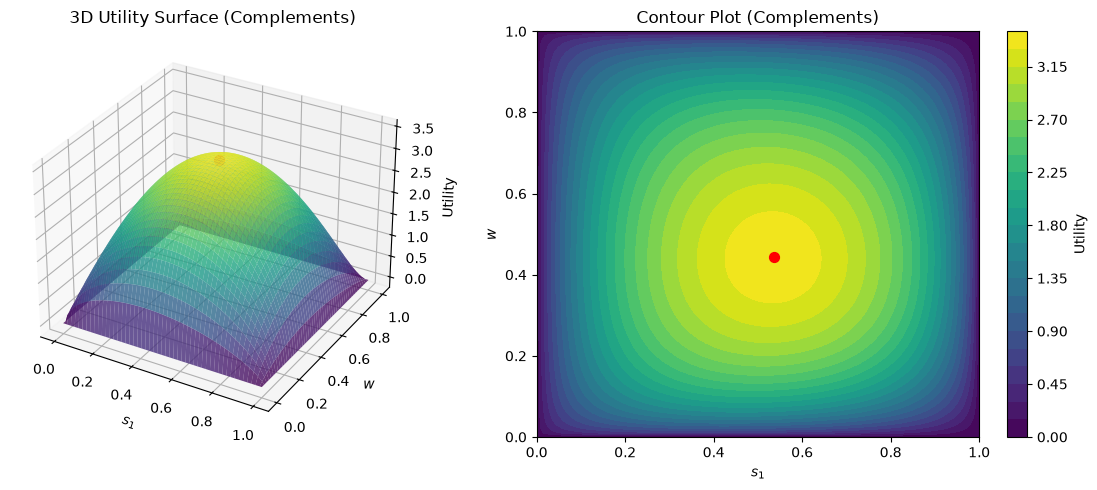

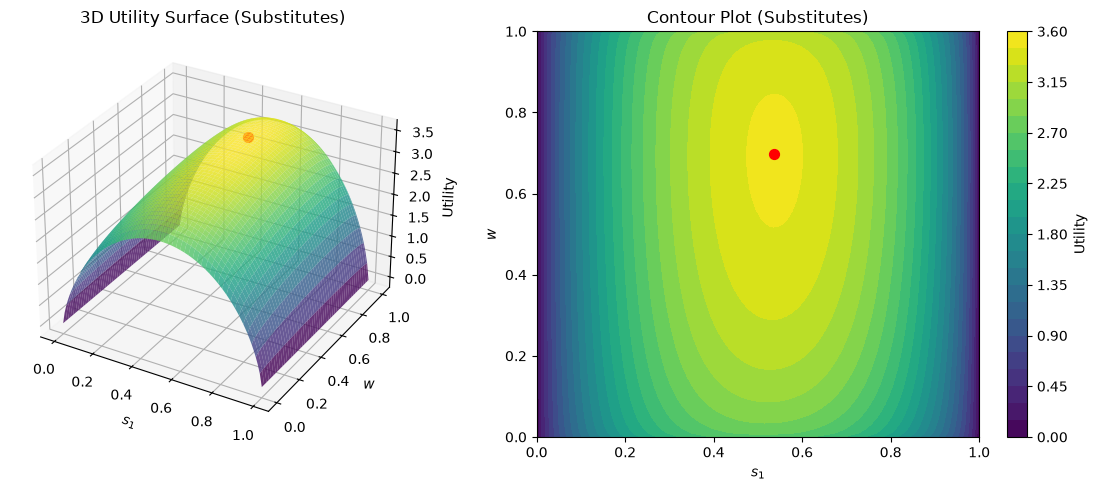

In [38]:
# a.  setting up a function for plotting
def plot_utility(sol, title):
    """ Plots utility in 3D and as a contour plot """
    
    # i. setup figure
    fig = plt.figure(figsize=(12, 5))
    
    # ii. 3D surface plot
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    ax3d.plot_surface(sol.s1_grid, sol.w_grid, sol.u_grid, cmap='viridis', alpha=0.8)
    ax3d.scatter(sol.s1, sol.w, sol.u, color='red', s=50, label='Optimum')
    ax3d.set_title(f'3D Utility Surface ({title})')
    ax3d.set_xlabel('$s_1$') #allocation of good 1 (food)
    ax3d.set_ylabel('$w$') #income
    ax3d.set_zlabel('Utility') #Utility
    
    # iii. 2D contour plot
    ax_cont = fig.add_subplot(1, 2, 2)
    cs = ax_cont.contourf(sol.s1_grid, sol.w_grid, sol.u_grid, levels=30, cmap='viridis')
    fig.colorbar(cs, ax=ax_cont, label='Utility')
    ax_cont.scatter(sol.s1, sol.w, color='red', s=50, label='Optimum')
    ax_cont.set_title(f'Contour Plot ({title})')
    ax_cont.set_xlabel('$s_1$') #allocation of good 1 (food)
    ax_cont.set_ylabel('$w$') #income
    
    plt.tight_layout()
    plt.show()

# b. generating the plots
plot_utility(sol_comp, "Complements")
plot_utility(sol_sub, "Substitutes")

**2.1.3**

In [37]:
# d. testing different grid sizes (Question 3)
N_list = [50, 100, 500, 1000]

def test_grid_sizes(model, name):
    """ Tests the grid search for different values of N to check convergence """
    
    print(f"\nConvergence check for {name}:")
    print(f"{'N':<5} | {'Evaluations':<12} | {'s1':<8} | {'w':<8} | {'Utility':<10}") #titles
    print("-" * 55)
    
    for N in N_list:
        sol = model.solve_grid(N=N, do_print=False)
        evals = N * N # Total number of function evaluations
        print(f"{N:<5} | {evals:<12} | {sol.s1:.4f}   | {sol.w:.4f}   | {sol.u:.6f}")

test_grid_sizes(model_comp, "Complements")
test_grid_sizes(model_sub, "Substitutes")


Convergence check for Complements:
N     | Evaluations  | s1       | w        | Utility   
-------------------------------------------------------
50    | 2500         | 0.5306   | 0.4490   | 3.400748
100   | 10000        | 0.5354   | 0.4444   | 3.401482
500   | 250000       | 0.5351   | 0.4389   | 3.401674
1000  | 1000000      | 0.5355   | 0.4394   | 3.401680

Convergence check for Substitutes:
N     | Evaluations  | s1       | w        | Utility   
-------------------------------------------------------
50    | 2500         | 0.5306   | 0.6939   | 3.484594
100   | 10000        | 0.5354   | 0.6970   | 3.485005
500   | 250000       | 0.5391   | 0.6914   | 3.485097
1000  | 1000000      | 0.5385   | 0.6927   | 3.485104


As N increases, the solutions become more precise and utility approaches a stable maximum for both calibrations. However, the improvement is not smooth: the estimated s 
1
​	
  and w fluctuate slightly as the grid becomes finer, because the grid search is restricted to discrete grid points. At the same time, the computational cost increases rapidly, since the number of utility evaluations is N 
2
 , rising from 2,500 at N=50 to 1,000,000 at N=1000. Despite this large increase in evaluations, the improvement in utility becomes very small at high N, indicating diminishing gains from further refining the grid.

**2.1.4**

The two calibrations produce noticeably different utility surfaces. For complements, the surface is relatively steep in the w-direction around the optimum, indicating that deviations from the preferred mix of bus and train quickly reduce utility. In contrast, the substitutes calibration has a much flatter surface in the w-direction around the optimum, while utility changes more sharply in the s 
1
​	
 -direction. This reflects that when bus and train are highly substitutable, the consumer can change the allocation between them with relatively little loss in utility. Therefore, we would expect the substitutes calibration to be harder for an optimizer, since the relatively flat region around the optimum makes the exact optimal value of w more difficult to locate.

**PROBLEM 2.2**

**2.2.1**

In [12]:
#Compare grid search and L-BFGS-B for both calibrations

results = []

for model, name in [
    (model_comp, "Complements"),
    (model_sub, "Substitutes")
]:

    # a. Grid search with N = 1000
    start = time.perf_counter()
    sol_grid = model.solve_grid(N=1000, do_print=False)
    grid_time = time.perf_counter() - start

    results.append({
        "Calibration": name,
        "Method": "Grid search",
        "s1": sol_grid.s1,
        "w": sol_grid.w,
        "s2": sol_grid.s2,
        "s3": sol_grid.s3,
        "Utility": sol_grid.u,
        "Evaluations": 1000**2,
        "Time (sec.)": grid_time
    })

    # b. L-BFGS-B
    start = time.perf_counter()
    sol_bfgs = model.solve(
        s0=np.array([0.5, 0.5]),
        do_print=False
    )
    bfgs_time = time.perf_counter() - start

    results.append({
        "Calibration": name,
        "Method": "L-BFGS-B",
        "s1": sol_bfgs.s1,
        "w": sol_bfgs.w,
        "s2": sol_bfgs.s2,
        "s3": sol_bfgs.s3,
        "Utility": sol_bfgs.u,
        "Evaluations": sol_bfgs.res.nfev,
        "Time (sec.)": bfgs_time
    })

# c. Create comparison table
df_compare = pd.DataFrame(results)

display(
    df_compare.round({
        "s1": 4,
        "w": 4,
        "s2": 4,
        "s3": 4,
        "Utility": 6,
        "Time (sec.)": 6
    })
)

NameError: name 'time' is not defined

The L-BFGS-B and grid search methods produce almost identical solutions for both calibrations. The optimal budget shares and utility levels are virtually the same, indicating that both methods agree on the location of the optimum.

However, L-BFGS-B is substantially more efficient. The grid search requires 1,000,000 utility evaluations for each calibration, whereas L-BFGS-B only requires 18 evaluations for complements and 27 for substitutes. This is also reflected in the running time, which falls from approximately 0.10 to 0.001 seconds for complements and from 0.07 to 0.002 seconds for substitutes. Thus, L-BFGS-B reaches essentially the same solution at a fraction of the computational cost.

**2.2.2**

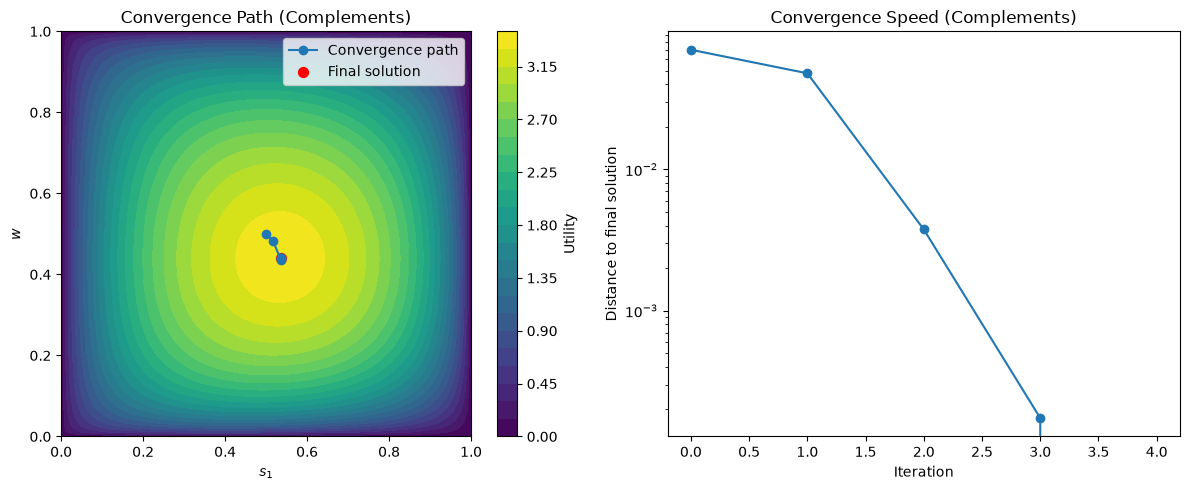

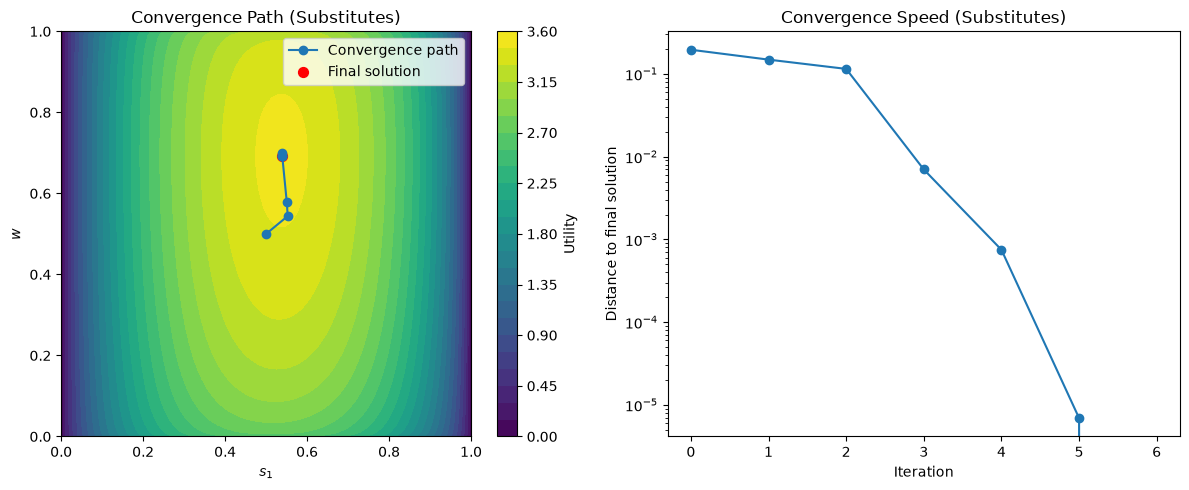

In [ ]:
# a. solve with L-BFGS-B

sol_bfgs_comp = model_comp.solve(
    s0=np.array([0.5, 0.5]),
    do_print=False
)

sol_bfgs_sub = model_sub.solve(
    s0=np.array([0.5, 0.5]),
    do_print=False
)


# b. function for plotting convergence path

def plot_convergence(sol_grid, sol_bfgs, title):
    """Plot convergence path and distance to final solution"""

    # i. convergence path
    path = np.array(sol_bfgs.path)

    # ii. final solution
    s_star = np.array([sol_bfgs.s1, sol_bfgs.w])

    # iii. distance from each iteration to the final solution
    distance = np.linalg.norm(path - s_star, axis=1)

    # iv. setup figure
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # v. convergence path on contour plot
    cs = ax[0].contourf(
        sol_grid.s1_grid,
        sol_grid.w_grid,
        sol_grid.u_grid,
        levels=30,
        cmap='viridis'
    )

    fig.colorbar(cs, ax=ax[0], label='Utility')

    ax[0].plot(
        path[:, 0],
        path[:, 1],
        '-o',
        label='Convergence path'
    )

    ax[0].scatter(
        sol_bfgs.s1,
        sol_bfgs.w,
        color='red',
        s=50,
        label='Final solution'
    )

    ax[0].set_xlabel('$s_1$')
    ax[0].set_ylabel('$w$')
    ax[0].set_title(f'Convergence Path ({title})')
    ax[0].legend()

    # vi. distance to final solution
    ax[1].plot(
        np.arange(len(distance)),
        distance,
        '-o'
    )

    ax[1].set_yscale('log')
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Distance to final solution')
    ax[1].set_title(f'Convergence Speed ({title})')

    plt.tight_layout()
    plt.show()


# c. plot convergence for both calibrations

plot_convergence(
    sol_comp,
    sol_bfgs_comp,
    'Complements'
)

plot_convergence(
    sol_sub,
    sol_bfgs_sub,
    'Substitutes'
)

The convergence paths show that L-BFGS-B successfully reaches the optimum for both calibrations. For complements, the method converges quickly and directly in only a few iterations. For substitutes, progress is slower in the first iterations, but accelerates considerably as the solver approaches the optimum. Overall, convergence is somewhat slower for substitutes, which is consistent with the flatter utility surface around the optimum.

**2.2.3**

In [ ]:
# a. starting points

starting_points = {
    'Middle': np.array([0.5, 0.5]),
    'Corner (0,0)': np.array([0.0, 0.0]),
    'Corner (0,1)': np.array([0.0, 1.0]),
    'Corner (1,0)': np.array([1.0, 0.0]),
    'Corner (1,1)': np.array([1.0, 1.0]),
    'Interior': np.array([0.25, 0.75])
}


# b. function for testing starting points

def test_starting_points(model, name):
    """Solve the model from different starting points"""

    results = []

    for label, s0 in starting_points.items():

        sol = model.solve(
            s0=s0,
            do_print=False
        )

        results.append({
            'Calibration': name,
            'Starting point': label,
            's1': sol.s1,
            'w': sol.w,
            'Utility': sol.u,
            'Iterations': sol.res.nit,
            'Evaluations': sol.res.nfev,
            'Success': sol.res.success
        })

    return results


# c. run for both calibrations

results_start = []

results_start += test_starting_points(
    model_comp,
    'Complements'
)

results_start += test_starting_points(
    model_sub,
    'Substitutes'
)


# d. create table

df_start = pd.DataFrame(results_start)

display(
    df_start.round({
        's1': 4,
        'w': 4,
        'Utility': 6
    })
)

,Calibration,Starting point,s1,w,Utility,Iterations,Evaluations,Success
0,Complements,Middle,0.5356,0.4395,3.401680,4,18,True
1,Complements,"Corner (0,0)",0.5356,0.4395,3.401680,7,27,True
2,Complements,"Corner (0,1)",0.5356,0.4395,3.401680,9,33,True
3,Complements,"Corner (1,0)",1.0000,0.0000,0.000000,1,21,True
4,Complements,"Corner (1,1)",1.0000,1.0000,0.000000,1,21,True
5,Complements,Interior,0.5356,0.4395,3.401680,6,24,True
6,Substitutes,Middle,0.5382,0.6923,3.485105,6,27,True
7,Substitutes,"Corner (0,0)",0.5382,0.6923,3.485105,18,72,True
8,Substitutes,"Corner (0,1)",0.5382,0.6923,3.485105,17,66,True
9,Substitutes,"Corner (1,0)",0.5382,0.6923,3.485105,18,81,True


For most starting points, L-BFGS-B converges to the same optimum, although the number of iterations varies considerably with the starting point. The substitutes calibration converges to the same solution from all tested starting points, but generally requires more iterations from the corners. For the complements calibration, starting at s 
1
​	
 =1 causes a numerical problem. At this boundary, the entire budget is spent on food and the travel quantities are zero. Because the goods in the lower nest are complements, utility is extremely low and the objective behaves poorly numerically near the corner. L-BFGS-B may therefore interpret the numerical gradient as satisfying its convergence criterion and stop at the boundary, even though a much better interior solution exists. This explains why the solver can report success = True without finding the actual optimum.

**2.2.4**

In [ ]:
import pandas as pd

# a. tolerance values

ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]
gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]


# b. function for testing tolerances

def test_tolerances(model, name):
    """Test different ftol and gtol values for L-BFGS-B"""

    results = []

    # i. vary ftol
    for ftol in ftol_values:

        sol = model.solve(
            do_print=False,
            options={'ftol': ftol}
        )

        results.append({
            'Calibration': name,
            'Setting': 'ftol',
            'Tolerance': ftol,
            's1': sol.s1,
            'w': sol.w,
            'Utility': sol.u,
            'Evaluations': sol.res.nfev
        })

    # ii. vary gtol
    for gtol in gtol_values:

        sol = model.solve(
            do_print=False,
            options={'gtol': gtol}
        )

        results.append({
            'Calibration': name,
            'Setting': 'gtol',
            'Tolerance': gtol,
            's1': sol.s1,
            'w': sol.w,
            'Utility': sol.u,
            'Evaluations': sol.res.nfev
        })

    return results


# c. run for both calibrations

results_tol = []

results_tol += test_tolerances(
    model_comp,
    'Complements'
)

results_tol += test_tolerances(
    model_sub,
    'Substitutes'
)


# d. create table

df_tol = pd.DataFrame(results_tol)

display(
    df_tol.round({
        's1': 6,
        'w': 6,
        'Utility': 8
    })
)

,Calibration,Setting,Tolerance,s1,w,Utility,Evaluations
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


**2.2.5**

Based on the results, ftol = 1e-8 appears to provide a good balance between accuracy and computational cost. Tightening the tolerance further does not improve the achieved utility, while stricter settings may require additional function evaluations. A tighter tolerance is therefore not always better, since another stopping criterion may become binding and numerical precision limits how much the solution can be improved.

**PROBLEM 3: Relative prices and demand**

**PROBLEM 3.1**

**PROBLEM 3.2**

**PROBLEM 3.3**

**PROBLEM 3.4**

**PROBLEM 4: Lump-sum taxes and product taxes**

**PROBLEM 4.1**

In [ ]:
# a. setup government models
from Government import GovernmentClass
gov_comp = GovernmentClass()                       # Complements
gov_sub = GovernmentClass(par={'sigma_B': 3.0})   # Substitutes

**PROBLEM 4.2**

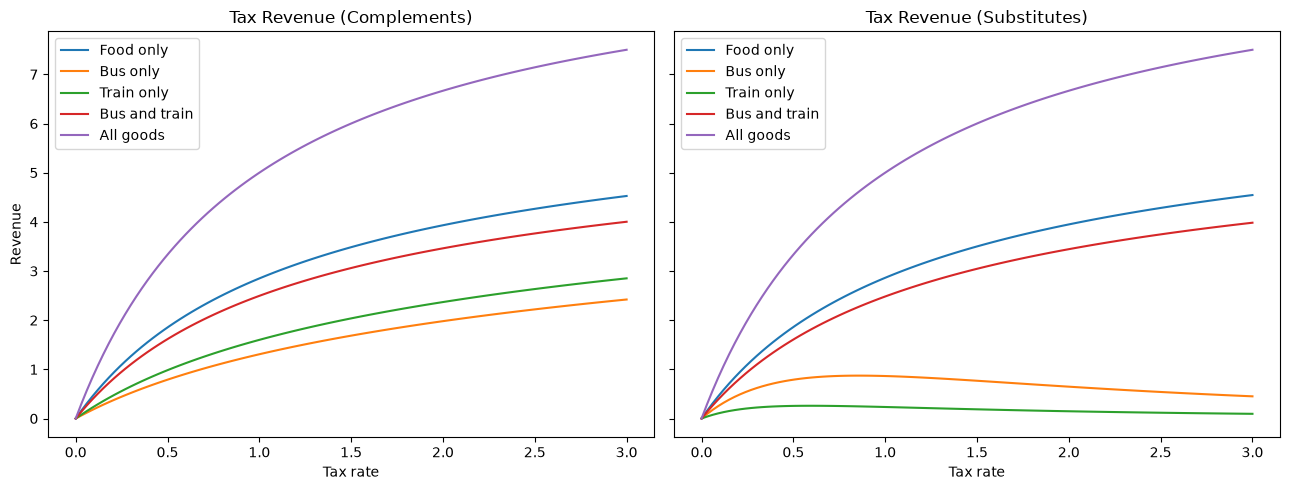

In [ ]:
# tax rates implemented in the GovernmentClass
tau_grid = np.linspace(0, 3, 101)

# tax instruments
taxes = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All goods': (1,2,3)
}

# function for calculating revenue curves
def revenue_curves(model):

    revenues = {}

    for name, goods in taxes.items():

        R_vec = np.empty(len(tau_grid))

        for i, tau in enumerate(tau_grid):
            R_vec[i], _ = model.revenue_and_utility(
                tau,
                goods=goods
            )

        revenues[name] = R_vec

    return revenues

# calculate revenues
R_comp = revenue_curves(gov_comp)
R_sub = revenue_curves(gov_sub)

# plotting the revenue curves
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for name in taxes.keys():
    ax[0].plot(
        tau_grid,
        R_comp[name],
        label=name
    )

    ax[1].plot(
        tau_grid,
        R_sub[name],
        label=name
    )

# Complements
ax[0].set_title('Tax Revenue (Complements)')
ax[0].set_xlabel('Tax rate')
ax[0].set_ylabel('Revenue')
ax[0].legend()

# Substitutes
ax[1].set_title('Tax Revenue (Substitutes)')
ax[1].set_xlabel('Tax rate')
ax[1].legend()

plt.tight_layout()
plt.show()

**PROBLEM 4.3**

In [ ]:
# a. tax instruments
taxes = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All goods': (1,2,3)
}

# b. function for finding maximum revenue
def find_max_revenues(model, calibration, tau_max=10.0, N=1001):

    results = []

    for name, goods in taxes.items():

        tau_star, R_max = model.max_revenue(
            goods=goods,
            tau_max=tau_max,
            N=N
        )

        results.append({
            'Calibration': calibration,
            'Tax instrument': name,
            'Revenue-maximizing rate': tau_star,
            'Maximum revenue': R_max,
            'At upper bound': np.isclose(tau_star, tau_max)
        })

    return results


# c. run for both calibrations
results_max = []

results_max += find_max_revenues(
    gov_comp,
    'Complements',
    tau_max=10.0,
    N=1001
)

results_max += find_max_revenues(
    gov_sub,
    'Substitutes',
    tau_max=10.0,
    N=1001
)

# d. create table
df_max = pd.DataFrame(results_max)

display(
    df_max.round({
        'Revenue-maximizing rate': 4,
        'Maximum revenue': 6
    })
)

,Calibration,Tax instrument,Revenue-maximizing rate,Maximum revenue,At upper bound
0,Complements,Food only,10.00,5.915863,True
1,Complements,Bus only,10.00,3.752406,True
2,Complements,Train only,10.00,4.215998,True
3,Complements,Bus and train,10.00,5.303850,True
4,Complements,All goods,10.00,9.090909,True
5,Substitutes,Food only,10.00,5.937453,True
6,Substitutes,Bus only,0.86,0.872136,False
7,Substitutes,Train only,0.59,0.259037,False
8,Substitutes,Bus and train,10.00,5.280709,True
9,Substitutes,All goods,10.00,9.090909,True


The results show a clear difference between the two calibrations. For complements, none of the five revenue curves reaches a maximum within the considered range, as the revenue-maximizing rate is always found at the upper bound. For substitutes, the food-only, bus-and-train, and all-goods taxes also continue to increase, while the bus-only and train-only taxes have clear revenue maxima. In particular, the train-only tax reaches its maximum revenue of approximately 0.259 at a tax rate of about 0.59. Thus, a tax on train tickets alone can never raise substantially more than 0.259 in the substitutes calibration.

**PROBLEM 4.4**

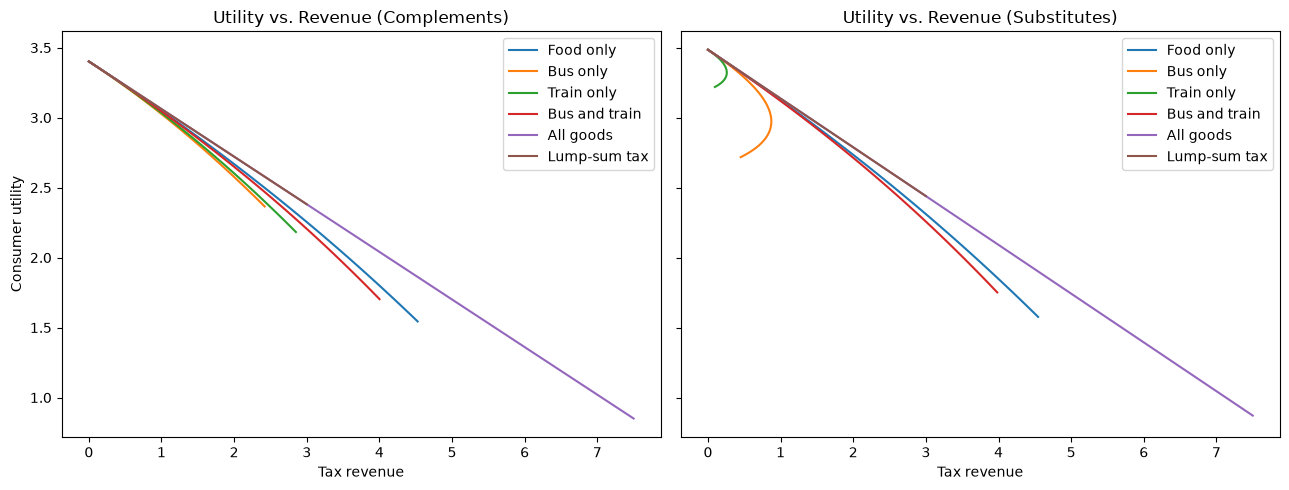

In [ ]:
# a. tax rates and lump-sum taxes

tau_grid = np.linspace(0, 3, 101)
T_grid = np.linspace(0, 3, 101)

# b. tax instruments

taxes = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All goods': (1,2,3)
}


# c. function for calculating revenue and utility curves

def utility_revenue_curves(model):

    results = {}

    # i. product taxes
    for name, goods in taxes.items():

        R_vec = np.empty(len(tau_grid))
        u_vec = np.empty(len(tau_grid))

        for i, tau in enumerate(tau_grid):
            R_vec[i], u_vec[i] = model.revenue_and_utility(
                tau,
                goods=goods
            )

        results[name] = (R_vec, u_vec)

    # ii. lump-sum tax
    R_lump = np.empty(len(T_grid))
    u_lump = np.empty(len(T_grid))

    for i, T in enumerate(T_grid):
        R_lump[i], u_lump[i] = model.revenue_and_utility_lump_sum(T)

    results['Lump-sum tax'] = (R_lump, u_lump)

    return results


# d. calculate curves for both calibrations

curves_comp = utility_revenue_curves(gov_comp)
curves_sub = utility_revenue_curves(gov_sub)


# e. plot utility against revenue

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for name in curves_comp.keys():

    R_comp, u_comp = curves_comp[name]
    R_sub, u_sub = curves_sub[name]

    ax[0].plot(
        R_comp,
        u_comp,
        label=name
    )

    ax[1].plot(
        R_sub,
        u_sub,
        label=name
    )


# Complements
ax[0].set_title('Utility vs. Revenue (Complements)')
ax[0].set_xlabel('Tax revenue')
ax[0].set_ylabel('Consumer utility')
ax[0].legend()


# Substitutes
ax[1].set_title('Utility vs. Revenue (Substitutes)')
ax[1].set_xlabel('Tax revenue')
ax[1].legend()


plt.tight_layout()
plt.show()

The lump-sum tax is the cheapest way to raise a given amount of revenue in both calibrations, since it leaves the consumer with the highest utility for any given revenue level. Among the product taxes, taxing all goods at the same rate performs relatively well, while taxes on individual goods generally create larger utility losses. The ranking is broadly similar across the two calibrations, although the substitutes calibration shows a particularly poor performance for taxes on bus or train alone because the consumer can substitute strongly between the two transport goods.

**PROBLEM 4.5**

In [ ]:
# a. target revenue

R_target = 0.20

# b. tax instruments

taxes = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All goods': (1,2,3)
}


# c. function for finding the first bracket with a root

def find_bracket(model, goods, R_target, tau_max=3.0, N=301):

    tau_grid = np.linspace(0, tau_max, N)

    R_grid = np.empty(N)

    for i, tau in enumerate(tau_grid):
        R_grid[i], _ = model.revenue_and_utility(
            tau,
            goods=goods
        )

    # Find the first interval where R - R_target changes sign
    f = R_grid - R_target

    for i in range(N-1):

        if f[i] * f[i+1] <= 0:
            return (tau_grid[i], tau_grid[i+1])

    return None


# d. function for solving all tax instruments

def solve_tax_requirement(model, calibration):

    results = []

    # i. product taxes
    for name, goods in taxes.items():

        bracket = find_bracket(
            model,
            goods,
            R_target
        )

        if bracket is not None:

            tau = model.find_tax_rate(
                R_target,
                goods=goods,
                bracket=bracket
            )

            R, u = model.revenue_and_utility(
                tau,
                goods=goods
            )

        else:

            tau = np.nan
            R = np.nan
            u = np.nan

        results.append({
            'Calibration': calibration,
            'Tax instrument': name,
            'Tax rate': tau,
            'Revenue': R,
            'Utility': u
        })

    # ii. lump-sum tax
    T = R_target

    R, u = model.revenue_and_utility_lump_sum(T)

    results.append({
        'Calibration': calibration,
        'Tax instrument': 'Lump-sum tax',
        'Tax rate': T,
        'Revenue': R,
        'Utility': u
    })

    return results

# e. solve for both calibrations

results_comp = solve_tax_requirement(
    gov_comp,
    'Complements'
)

results_sub = solve_tax_requirement(
    gov_sub,
    'Substitutes'
)

df_comp = pd.DataFrame(results_comp)
df_sub = pd.DataFrame(results_sub)

# f. rank instruments by utility

df_comp = df_comp.sort_values(
    'Utility',
    ascending=False
).reset_index(drop=True)

df_comp['Rank'] = np.arange(1, len(df_comp)+1)


df_sub = df_sub.sort_values(
    'Utility',
    ascending=False
).reset_index(drop=True)

df_sub['Rank'] = np.arange(1, len(df_sub)+1)


# g. display tables

print('--- Complements ---')
display(
    df_comp[
        ['Rank', 'Tax instrument', 'Tax rate', 'Revenue', 'Utility']
    ].round({
        'Tax rate': 6,
        'Revenue': 6,
        'Utility': 6
    })
)

print('--- Substitutes ---')
display(
    df_sub[
        ['Rank', 'Tax instrument', 'Tax rate', 'Revenue', 'Utility']
    ].round({
        'Tax rate': 6,
        'Revenue': 6,
        'Utility': 6
    })
)

--- Complements ---


,Rank,Tax instrument,Tax rate,Revenue,Utility
0,1,Lump-sum tax,0.200000,0.2,3.333646
1,2,All goods,0.020408,0.2,3.333646
2,3,Food only,0.038647,0.2,3.333169
3,4,Bus and train,0.044787,0.2,3.333010
4,5,Train only,0.081011,0.2,3.332548
5,6,Bus only,0.104215,0.2,3.332260


--- Substitutes ---


,Rank,Tax instrument,Tax rate,Revenue,Utility
0,1,All goods,0.020408,0.2,3.415402
1,2,Lump-sum tax,0.200000,0.2,3.415402
2,3,Food only,0.038454,0.2,3.414919
3,4,Bus and train,0.045049,0.2,3.414744
4,5,Bus only,0.069532,0.2,3.412375
5,6,Train only,0.236217,0.2,3.395521


The ranking is very similar across the two calibrations. The lump-sum tax and the uniform tax on all goods are the best instruments, as they leave the consumer with the highest utility while raising the required revenue. Taxes on individual goods perform worse because they distort relative prices. In the complements calibration, the train-only tax performs slightly better than the bus-only tax, while in the substitutes calibration the train-only tax is clearly the worst instrument. This is because consumers can substitute strongly away from train travel when train tickets are taxed, so a much higher tax rate is required to raise the target revenue, creating a larger utility loss.

**PROBLEM 5: Extension**

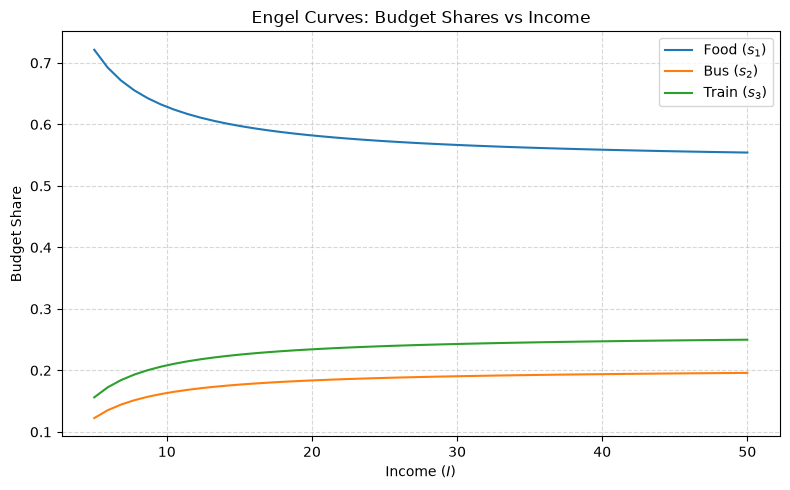

In [13]:
# a. imports
from ExtendedConsumer import ExtendedConsumerClass 

# b. setup the extended model
model_ext = ExtendedConsumerClass(par={'sigma_B': 0.40}) # Using Complements

# c. define income grid
incomes = np.linspace(5.0, 50.0, 50)

# d. initialize result arrays
s1_shares = np.zeros(len(incomes))
s2_shares = np.zeros(len(incomes))
s3_shares = np.zeros(len(incomes))

# e. loop over incomes and solve
for i, I_val in enumerate(incomes):
    
    # i. update income parameter
    model_ext.par.I = I_val
    
    # ii. solve model
    sol = model_ext.solve(do_print=False)
    
    # iii. extract quantities
    x1, x2, x3 = model_ext.quantities(sol.s1, sol.w)
    
    # iv. compute actual budget shares (spending / total income)
    s1_shares[i] = (model_ext.par.p1 * x1) / I_val
    s2_shares[i] = (model_ext.par.p2 * x2) / I_val
    s3_shares[i] = (model_ext.par.p3 * x3) / I_val

# f. plot the Engel curves (budget shares)
fig, ax = plt.subplots(figsize=(8, 5))

# i. plot lines
ax.plot(incomes, s1_shares, label='Food ($s_1$)')
ax.plot(incomes, s2_shares, label='Bus ($s_2$)')
ax.plot(incomes, s3_shares, label='Train ($s_3$)')

# ii. format plot
ax.set_title('Engel Curves: Budget Shares vs Income')
ax.set_xlabel('Income ($I$)')
ax.set_ylabel('Budget Share')
ax.legend()
ax.grid(True, ls='--', alpha=0.5)

# iii. show plot
plt.tight_layout()
plt.show()